# 20.15. Анатомический выбор места боковых электродных сборок

**Назначение.** Разработать воспроизводимое правило выбора области установки, ориентации и размеров боковых сборок, при котором плоская двуслойная модель позволяет достаточно точно определять эффективные сопротивления мягких тканей и лёгкого. Правило должно учитывать различия анатомии между людьми и ограничивать чувствительность к сердцу и другим органам.

**Статус на 10 сентября 2026 года.** Сформулирован протокол, выполнены аналитические демонстрации чувствительности и первичная инвентаризация скачанных архивов. Поиск места на открытых КТ, проверка сегментаций и межсубъектное сравнение FEM в этом ноутбуке ещё не выполнены. Оптимальное место и допустимые численные пороги не установлены. Этап относится к разработке методики.

Автор подтвердил требования к геометрии и информативности и добавил удалённость от других органов, прежде всего сердца. Правый бок первоначально выбран именно для ограничения сердечного вклада. Эти сведения задают мотивацию исследования; они не доказывают ни оптимальность правого бока, ни его непригодность.

## 1. Две исследовательские ветви и место нового этапа

| Ветвь | Что фиксируется | Что подбирается | Основной результат |
|---|---|---|---|
| Уточнение модели для существующего монтажа | Конкретное расположение сборок | Упрощённое представление толщины, кривизны и конечного объёма лёгкого | Быстрый прямой оператор с проверенной ошибкой обоих сопротивлений |
| Выбор места для простой модели — настоящий этап | Семейство плоских двуслойных моделей | Анатомическая область, ориентация и допустимые сочетания размеров | Переносимое правило установки и критерии отказа от простого приближения |

Первая ветвь развивается в [20.13](20.13_Геометрия_лёгкого_и_ошибка_восстановления_сопротивлений.ipynb) и [20.14](20.14_Две_проверки_моделей_с_литературными_сопротивлениями.ipynb). Настоящий этап конкретизирует вторую ветвь в рамках [20.11 — чувствительности](20.11_КТ_FEM_чувствительность_боковых_сборок.ipynb) и [20.12 — применимости моделей](20.12_Критерий_Lmax_плоскослоистой_модели.ipynb). Выбор информативной пары связан с серией 32, но здесь дополнительно ограничен анатомической пригодностью места.

В обеих ветвях нужны два вида проверки: синтетическое восстановление заранее заданных сопротивлений и сопоставление с экспериментальными импедансами, для которых истинные сопротивления неизвестны. Скачанные КТ позволяют выполнить первый вид проверки на разных анатомиях. Они сами по себе не предоставляют электрических измерений и истинных тканевых сопротивлений.

## 2. Физическая постановка и происхождение входов

Основная обратная задача сохраняет **две ткани и два сопротивления**: $\rho_1$ — эффективный фон всех областей вне лёгкого, включая ткани под диафрагмой; $\rho_2$ — лёгкое. В этой ветви фон также объединяет кости с остальными нелёгочными тканями по принятому двухтканному допущению. Геометрические маски сердца, печени и других органов сохраняются отдельно для контроля пространственной чувствительности; наличие маски не вводит третий подбираемый параметр.

В идеальной двуслойной модели кожа является плоскостью, граница лёгкого — параллельной плоскостью на глубине $h$, верхний слой однороден, нижний слой продолжается неограниченно в глубину и в стороны. **Плоская аналитическая задача** вычисляет решение этой постановки по формуле. **Плоская пространственная задача** решает уравнение проводимости численно в области с такими же плоскими границами. При согласованных электродах и граничных условиях их сравнение проверяет численную реализацию. Анатомическую пригодность проверяет отдельное сравнение с реальной КТ-геометрией.

| Вход | Происхождение и роль | Ограничение |
|---|---|---|
| Индивидуальная анатомия добровольцев | КТ и принятая автором ручная сегментация | Достоверность анатомии не определяет неизвестные сопротивления или фактическую позу электродов |
| Внешние КТ и сопровождающие маски | Скачанные исследовательские архивы; состав проверен по оглавлениям | Качество границ, полнота грудной клетки и независимость случаев ещё не проверены |
| Рабочие диапазоны сопротивлений | Литературная область этапа 20.14: примерно 1,377–10 и 9,741–24,074 Ом·м | Это рабочие границы, а не популяционные нормы для эффективных тканей при 50 кГц |
| Значения демонстрации: 4 и 16 Ом·м | Заданы внутри рабочей области | Не являются оценкой сопротивлений добровольца |
| Толщина демонстрации: 30 мм | Задана для объяснения зависимости от размера | Не измерена на конкретной КТ; в примерах считается точно известной |
| Размеры 50, 60, 70, 80, 90, 110, 120, 130, 140 мм | Набор размеров, соответствующий независимым записям Ника | В демонстрации используются идеальные номинальные точки, а не фактические контакты этих записей |

Рассматривается действительная скалярная проводимость в квазистатическом приближении, согласованная с ветвью 50 кГц. Анизотропия и ёмкостная составляющая явно не моделируются. Объединение последовательных записей разных размеров в одно физиологическое состояние остаётся допущением экспериментальной проверки. Полная КТ/FEM-постановка является вычислительным референсом, а не измерительным эталоном сопротивлений.

## 3. Геометрическая пригодность и определимость сопротивлений

Хорошее соответствие двуслойной геометрии означает, что упрощение анатомии вносит малую ошибку прямого расчёта. Определимость сопротивлений означает, что разные пары сопротивлений дают достаточно различимые наборы импедансов. Из первого свойства второе не следует.

Рассмотрим идеально плоскую грудную стенку над идеально плоским лёгочным полупространством. При малом размере сборки относительно толщины стенки влияние глубокого слоя на измерение может быть слабым. Изменение сопротивления лёгкого тогда почти не меняет импеданс, хотя геометрических нарушений двуслойной постановки вообще нет. Это контрпример утверждению «геометрическая точность гарантирует точность определения $\rho_2$».

Второй случай возникает, когда лёгкое заметно влияет на каждое измерение, но два размера имеют почти одинаковое соотношение чувствительности к тканям. Тогда увеличение одного сопротивления можно почти компенсировать уменьшением другого. Здесь ограничение определяется сходством измерений, а не только слабой чувствительностью к лёгкому.

**Следствие для выбора места.** Нельзя минимизировать только неплоскостность поверхностей или только ошибку импеданса. Требуется совместно проверять геометрию, разделимость тканевых параметров и посторонние анатомические вклады. Это не утверждение о неизбежном конфликте: место и размеры могут удовлетворять всем трём условиям.

## 4. Математическое описание чувствительности

Для малого изменения сопротивлений при фиксированной геометрии:

$$\delta Z_i\simeq J_{i1}\delta\rho_1+J_{i2}\delta\rho_2,\qquad
J_{ij}=\frac{\partial Z_i}{\partial\rho_j},$$

где $Z_i$ — передаточный импеданс сборки размера $i$ в Ом; $\rho_j$ — удельное сопротивление ткани $j$ в Ом·м; $J_{ij}$ — производная в м$^{-1}$; $\delta$ обозначает малое изменение. При неизвестном $h$ появляется дополнительный столбец производных, и два измерения в общем случае не определяют три неизвестных без дополнительной информации.

Для сравнения относительных изменений удобно использовать безразмерную матрицу:

$$A_{ij}=\frac{\rho_j}{Z_i}\frac{\partial Z_i}{\partial\rho_j},\qquad
\delta\ln|Z_i|\simeq A_{i1}\delta\ln\rho_1+A_{i2}\delta\ln\rho_2,$$

где $A_{ij}$ — относительная чувствительность, а логарифмическая запись применяется локально при ненулевом импедансе неизменного знака. В настоящих примерах импедансы положительны. Значение $A_{i2}=0{,}2$ означает: малое увеличение $\rho_2$ на 1% при фиксированных остальных входах изменит $Z_i$ примерно на 0,2%. Оно не означает автоматически, что 20% электрического тока проходит через лёгкое.

В точечной двухтканной постановке совместное умножение сопротивлений на один коэффициент умножает импеданс на тот же коэффициент. Поэтому $A_{i1}+A_{i2}=1$. Это тождество однородности относится к данной постановке: при фиксированных ненулевых контактных импедансах полной модели электродов такой вывод требует отдельного учёта контактного вклада. Кроме того, сумма, равная единице, сама по себе не запрещает отрицательные отдельные чувствительности.

Для двух размеров матрица имеет вид:

$$A=\begin{pmatrix}1-s_a&s_a\\1-s_b&s_b\end{pmatrix},\qquad
\det A=s_b-s_a,$$

где $s_a$ и $s_b$ — относительные чувствительности к лёгкому для двух сборок. Если они равны, матрица вырождена: малые изменения двух сопротивлений нельзя разделить по этим двум измерениям. Даже большие $s_a$ и $s_b$ не помогают, если их различие слишком мало.

Число обусловленности определяется как:

$$\kappa_2(A)=\frac{\sigma_{\max}(A)}{\sigma_{\min}(A)},$$

где $\sigma_{\max}$ и $\sigma_{\min}$ — наибольшее и наименьшее сингулярные числа. Большая $\kappa_2$ указывает на сильную неравномерность информативности разных сочетаний параметров. Она не является процентом ошибки или доверительным интервалом. Нужно сохранять также $\sigma_{\min}$: одинаковое число обусловленности может соответствовать разному абсолютному уровню чувствительности. Здесь нормировка относительная и невзвешенная; при заданных погрешностях каналов нормировку следует согласовать с ними.

## 5. Выполненный аналитический опыт и модель электродов

Вычисления ниже используют действующее аналитическое ядро серии 30. Электроды — четыре **идеальные точки** на одной прямой: токовые в координатах $-L/2$ и $+L/2$, измерительные в $-L/4$ и $+L/4$. Ток направлен от отрицательной к положительной координате; измеряется потенциал левой внутренней точки минус потенциал правой. Размер $L$ равен расстоянию между токовыми точками. Площадь электродов и контактное сопротивление отсутствуют. Нормировка тока — 1 А; результатом является отношение напряжения к току, и это не утверждение о токе экспериментального прибора.

Для этой геометрии используется сходящийся ряд изображений:

$$Z=\frac{\rho_1}{\pi}\left[\frac1{d_-}-\frac1{d_+}
+2\sum_{n=1}^{\infty}k^n\left(\frac1{\sqrt{d_-^2+(2nh)^2}}-
\frac1{\sqrt{d_+^2+(2nh)^2}}\right)\right],$$

где $d_-=L/4$, $d_+=3L/4$ — расстояния от токовой точки до ближней и дальней измерительных точек; $k=(\rho_2-\rho_1)/(\rho_2+\rho_1)$ — коэффициент отражения; $n$ — номер члена ряда; $h$ — толщина верхнего слоя. Длины в формуле выражены в метрах.

При фиксированном конечном контрасте и $L/h\to0$ основной член определяется $\rho_1$, а относительная поправка глубокого слоя убывает как величина порядка $(L/h)^3$. При противоположном пределе очень тонкого верхнего слоя относительно всех расстояний отклик приближается к однородному нижнему полупространству. Следовательно, крайние режимы могут терять информацию об одной из тканей. Полезность пары определяется различием её чувствительностей, а не стремлением сделать обе сборки максимально глубокими.

Проверки реализации включают однородный предел, тождество однородности и сопоставление аналитических производных с центральными конечными разностями. Они проверяют математический расчёт демонстрации. Сравнение с реальной анатомией в этом опыте отсутствует; нулевая геометрическая ошибка здесь является свойством заданного идеального объекта и не результатом проверки на КТ.

In [1]:
from pathlib import Path
import hashlib, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NB_DIR = Path.cwd()
if not (NB_DIR / 'two_layer_model.py').exists():
    NB_DIR = NB_DIR / 'Colab Notebooks'
assert (NB_DIR / 'two_layer_model.py').is_file(), 'Запускать из корня проекта или Colab Notebooks'
sys.path.insert(0, str(NB_DIR))
from two_layer_model import evaluate, geometry_from_size
RHO = np.array([4.0, 16.0])
H = 0.03
SIZES = np.array([50, 60, 70, 80, 90, 110, 120, 130, 140])

def response(size_mm, rho=RHO):
    ev = evaluate(*rho, H, *geometry_from_size(float(size_mm) / 1000))
    j = np.array([ev.d_rho1, ev.d_rho2])
    return ev.z, rho * j / ev.z

rows = []
fd_errors = []
for size in SIZES:
    z, a = response(size)
    rows.append([size, z, *a])
    assert abs(a.sum()-1) < 1e-10
    ev0 = evaluate(4, 4, H, *geometry_from_size(size/1000))
    exact = 4/np.pi * (1/(size/4000)-1/(3*size/4000))
    assert np.isclose(ev0.z, exact, rtol=1e-12)
    for j in range(2):
        for step in [1e-4, 5e-5]:
            plus, minus = RHO.copy(), RHO.copy()
            plus[j] *= np.exp(step); minus[j] *= np.exp(-step)
            numerical = (np.log(response(size, plus)[0])-np.log(response(size, minus)[0]))/(2*step)
            fd_errors.append(abs(numerical-a[j])/max(abs(a[j]), 1e-12))
assert max(fd_errors) < 1e-6
single = pd.DataFrame(rows, columns=['L, мм', 'Z, Ом', 'A₁: мягкие ткани', 'A₂: лёгкое'])
display(single.round(6))
print(f'Проверены 9 размеров и 36 центральных разностей; максимальное относительное расхождение производных: {max(fd_errors):.2e}.')
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':11, 'axes.spines.top':False, 'axes.spines.right':False})

,"L, мм","Z, Ом",A₁: мягкие ткани,A₂: лёгкое
0,50,71.626813,0.968594,0.031406
1,60,61.460250,0.951662,0.048338
2,70,54.496735,0.932308,0.067692
3,80,49.487947,0.911443,0.088557
4,90,45.740251,0.889848,0.110152
5,110,40.530743,0.846681,0.153319
6,120,38.642051,0.825806,0.174194
7,130,37.061619,0.805659,0.194341
8,140,35.711606,0.786323,0.213677


Проверены 9 размеров и 36 центральных разностей; максимальное относительное расхождение производных: 1.98e-10.


### 5.1. Относительная чувствительность и размер сборки

Таблица выше показывает значения прямого импеданса и относительных производных при одних и тех же сопротивлениях и толщине. Числа относятся к идеальному объекту, а не к измеренному размерному ряду. Далее показан непрерывный диапазон размеров только для объяснения зависимости.

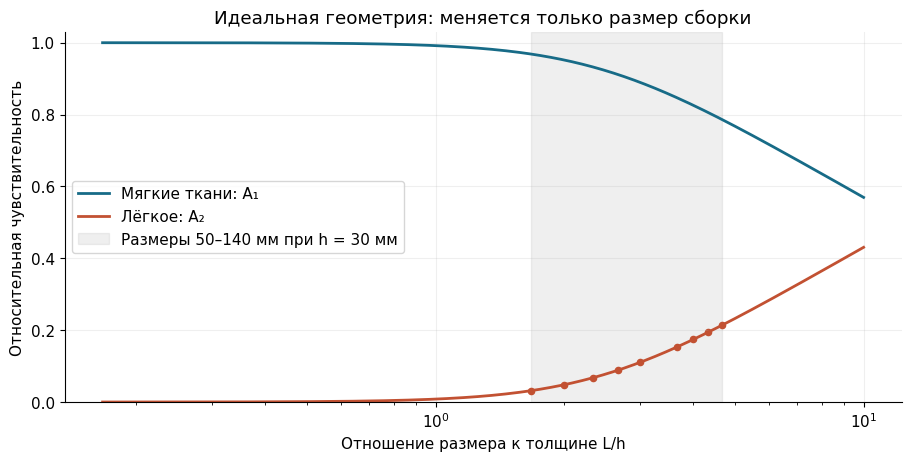

In [2]:
ls = np.geomspace(5, 300, 220)
aa = np.array([response(l)[1] for l in ls])
fig, ax = plt.subplots(figsize=(9,4.5), constrained_layout=True)
ax.plot(ls/H/1000, aa[:,0], label='Мягкие ткани: A₁', color='#176b87', lw=2)
ax.plot(ls/H/1000, aa[:,1], label='Лёгкое: A₂', color='#c25132', lw=2)
ax.axvspan(50/30, 140/30, alpha=.12, color='gray', label='Размеры 50–140 мм при h = 30 мм')
ax.scatter(SIZES/30, single['A₂: лёгкое'], color='#c25132', s=20)
ax.set(xscale='log', xlabel='Отношение размера к толщине L/h', ylabel='Относительная чувствительность', ylim=(0,1.03), title='Идеальная геометрия: меняется только размер сборки')
ax.legend(loc='center left'); ax.grid(alpha=.2)
plt.show()

**Рисунок 1.** По горизонтали отложено отношение размера к толщине; логарифмическая шкала позволяет видеть малые и большие отношения. По вертикали — относительная чувствительность каждой ткани. Точки обозначают девять выбранных размеров, серая полоса — их диапазон. Во всех точках геометрия остаётся строго плоской и двуслойной.

При малом $L/h$ красная кривая близка к нулю: сопротивление лёгкого слабо меняет измерение. В частности, изменение $\rho_2$ на 1% даёт локально около 0,0314% изменения импеданса для 50 мм и около 0,2137% для 140 мм. Это объясняет независимость геометрической пригодности и информативности. Ограничение рисунка — фиксированные сопротивления, точно известная толщина и точечные контакты. Монотонность этой конкретной кривой не является универсальным законом для реальной КТ-геометрии. Следующая проверка должна учитывать совместное восстановление обоих параметров.

## 6. Разделимость двух сопротивлений по паре размеров

Для каждой пары вычисляется матрица $A$. Дополнительно рассматривается условное ограничение: модуль относительного возмущения каждого импеданса не превышает 0,1%. Это заданный детерминированный сценарий, без предположения о распределении, независимости или экспериментально измеренном шуме.

В линейном приближении худшее отклонение второго логарифмического параметра для квадратной невырожденной матрицы равно:

$$\max_{|e_i|\leq\varepsilon}|\delta\ln\rho_2|
=\varepsilon\sum_i |(A^{-1})_{2i}|,$$

где $e_i=\delta Z_i/Z_i$ — относительное возмущение канала; $\varepsilon=0{,}001$ — заданная граница; $(A^{-1})_{2i}$ — элементы второй строки обратной матрицы. Равенство относится к линейной задаче с независимо допускаемыми знаками возмущений, а не к вероятностной модели. При больших получаемых отклонениях требуется полная нелинейная проверка с литературными ограничениями.

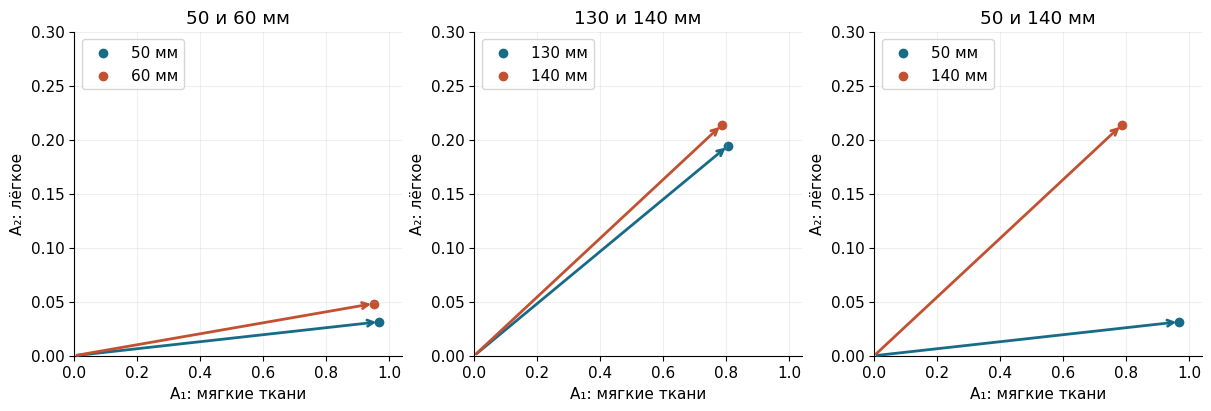

,"Размеры, мм",A₂ первого,A₂ второго,κ₂(A),σmin(A),"Линейная граница |δρ₂/ρ₂|, % при 0,1%"
0,50 и 60,0.0314,0.0483,109.0858,0.0125,11.3412
1,130 и 140,0.1943,0.2137,69.8463,0.0166,8.2333
2,50 и 140,0.0314,0.2137,8.6801,0.1449,0.9628


In [3]:
pairs = [(50,60), (130,140), (50,140)]
pair_rows = []
fig, axes = plt.subplots(1,3,figsize=(12,4), constrained_layout=True)
for ax, pair in zip(axes,pairs):
    a = np.array([response(l)[1] for l in pair])
    s = np.linalg.svd(a,compute_uv=False)
    gain = np.abs(np.linalg.inv(a)[1]).sum()
    pair_rows.append([f'{pair[0]} и {pair[1]}', *a[:,1], s[0]/s[-1], s[-1], gain*.1])
    for row, label, color in zip(a,pair,['#176b87','#c25132']):
        ax.annotate('',xy=row,xytext=(0,0),arrowprops={'arrowstyle':'->','color':color,'lw':2})
        ax.scatter(*row,color=color,label=f'{label} мм')
    ax.set(xlim=(0,1.04),ylim=(0,.3),xlabel='A₁: мягкие ткани',ylabel='A₂: лёгкое',title=f'{pair[0]} и {pair[1]} мм')
    ax.grid(alpha=.2); ax.legend(loc='upper left')
plt.show()
pair_table = pd.DataFrame(pair_rows,columns=['Размеры, мм','A₂ первого','A₂ второго','κ₂(A)','σmin(A)','Линейная граница |δρ₂/ρ₂|, % при 0,1%'])
display(pair_table.round(4))

**Рисунок 2.** Каждая стрелка задаёт строку матрицы относительных чувствительностей: её горизонтальная координата относится к мягким тканям, вертикальная — к лёгкому. Во всех панелях одинаковые масштабы осей; их разный горизонтальный и вертикальный диапазон увеличивает видимый угол. Число обусловленности вычислено по исходной матрице, а не по углам на растянутом изображении.

Почти совпадающие направления означают, что два размера видят сходные сочетания сопротивлений. Пара 130 и 140 мм сильнее чувствует лёгкое, чем пара 50 и 60 мм, но различие её чувствительностей всё ещё невелико. Пара 50 и 140 мм даёт более различающиеся сочетания вкладов и лучше разделяет параметры в данном опыте.

Таблица под рисунком показывает: для 130 и 140 мм число обусловленности составляет около 69,85, а для 50 и 140 мм — 8,68. При заданном возмущении до 0,1% линейные границы ошибки $\rho_2$ составляют соответственно около 8,23% и 0,96%. Это свойства локального идеального расчёта. Они не являются достигнутой точностью прибора, доверительными интервалами или рекомендацией использовать именно 50 и 140 мм на человеке. Следующий шаг — проверить сохранение различий при вариациях сопротивлений, анатомии, контактов и установки.

## 7. Общий критерий выбора: три независимые проверки

| Проверка | Что должно быть установлено | Что её не заменяет |
|---|---|---|
| Пригодность плоской геометрии | Допустимая ошибка прямого отклика и восстановления обоих сопротивлений относительно КТ/FEM | Визуально ровная кожа или совпадение одной точки $Z$ |
| Информативность | Устойчивая разделимость $\rho_1$ и $\rho_2$ для выбранного набора размеров | Только высокая чувствительность к лёгкому или физиологичные границы оптимизатора |
| Ограничение посторонних вкладов | Малое влияние сердца и других органов, вклад которых требуется ограничить, в заданных сценариях | Само название «правый бок» или большое расстояние до центра сердца |

Физиологически допустимая оценка обязательна, но недостаточна: две существенно разные пары внутри рабочей области могут давать близкие импедансы. Попадание оптимизатора на границу нужно показывать отдельно. Нулевая изменчивость параметра, удерживаемого границей, не доказывает его точного определения.

Для каждого места сначала определяется допустимый набор размеров по геометрии и посторонним вкладам, затем внутри него ищутся информативные пары. Если пересечения нет, место признаётся непригодным для выбранной простой постановки. При немонотонной ошибке сохраняется набор допустимых размеров; заменять его одним $L_{\max}$ нельзя. Достаточность пары требует отдельного сравнения с полным многоразмерным набором.

## 8. Анатомические критерии до расчёта электрического поля

Кандидат описывается областью кожи, центром в анатомической системе координат, направлением сборки и набором размеров. Продольное и поперечное направления задаются в локальной касательной плоскости кожи. Расстояние до ближайшей точки лёгкого и расстояние вдоль нормали кожи являются разными величинами; способ определения $h$ необходимо фиксировать.

| Критерий | Измеряемый признак | Физическое основание и ограничение |
|---|---|---|
| Однородность толщины стенки | Карта $h(s,t)$, среднее и разброс на одной и той же области | Одно $h$ должно представлять область чувствительности; вогнутые границы и отсутствие пересечения нормали нельзя заменять произвольной толщиной |
| Плоскостность обеих поверхностей | Отклонения кожи и плевральной границы от локальных плоскостей, две главные кривизны | Постоянная толщина между двумя кривыми поверхностями не делает их плоскими |
| Приблизительная параллельность | Угол между локальными нормалями и его изменение | Наклон границы перераспределяет глубину и направление проводящих путей |
| Удалённость от края лёгкого и диафрагмы | Минимальные расстояния до границ относительно размера сборки | Лёгкое должно занимать достаточную часть значимого объёма, а не только точки под электродами |
| Достаточная глубина лёгочной области | Расстояние до возврата в нелёгочную ткань вдоль выбранных направлений | Конечное лёгкое отличается от нижнего полупространства |
| Удалённость от сердца и других органов | Расстояние от всей области монтажа до ближайшей поверхности сердца, печени, крупных сосудов и других размеченных областей | Предварительный геометрический отсев; электрический вклад зависит также от полей и свойств тканей |
| Воспроизводимость установки | Изменение перечисленных признаков при сдвиге и повороте; доступность внешних ориентиров | Оптимум в одной точке КТ может быть непригоден для ручной установки |
| Переносимость между людьми и состояниями | Сохранение признаков в анатомически сопоставимых областях | Один доброволец и одна фаза дыхания не задают универсального правила |

Для сравнения анатомий целесообразны безразмерные признаки: относительный разброс $h$, отношение размера к каждому радиусу кривизны, расстояние до края лёгкого или органа, делённое на размер сборки. Они являются кандидатными признаками отбора; численные пороги не утверждены и не заменяют электрическую проверку. Начальную область анализа следует расширять за контур электродов и проверять устойчивость показателей при её расширении, поскольку поле не ограничено вертикальным столбиком под сборкой.

## 9. Сердце и другие органы: расстояние и действительный вклад

Добавленный автором критерий выделен отдельно от двуслойности: даже относительно ровные границы стенки и лёгкого не гарантируют малого сердечного вклада. С другой стороны, большое расстояние не является абсолютной гарантией слабого электрического влияния.

Для действительной изотропной проводимости и фиксированной геометрии локальную чувствительность к удельному сопротивлению можно записать через взаимное поле:

$$K_i^{\rho}(\mathbf x)=\frac{\mathbf j_i^{\mathrm{ток}}(\mathbf x)\cdot
\mathbf j_i^{\mathrm{взаим}}(\mathbf x)}{I_i^{\mathrm{ток}} I_i^{\mathrm{взаим}}},\qquad
\delta Z_i\simeq\int_\Omega K_i^{\rho}(\mathbf x)\,\delta\rho(\mathbf x)\,dV,$$

где $\Omega$ — объём проводника; $\mathbf x$ — точка; $\mathbf j$ — плотности тока в А/м²; первое поле создаёт токовая пара, второе — ток через измерительную пару; $I$ — соответствующие нормировочные токи в А; $K_i^{\rho}$ имеет размерность м$^{-4}$; $dV$ — элемент объёма. Контактные условия при вычислении взаимного поля должны соответствовать прямой задаче. Знак ядра определяется скалярным произведением полей: возможны положительные и отрицательные области.

Такое описание чувствительности и зависимость её распределения от геометрии электродов представлены в [работе Rutkove, Pacheck и Sanchez](https://pmc.ncbi.nlm.nih.gov/articles/PMC5498265/). Исследование относится к импедансной миографии; здесь используется общий аппарат взаимных полей, а его численные результаты не переносятся на лёгкое. Нелинейность и отрицательные области чувствительности также исследованы [Naydenova и соавторами](https://pubmed.ncbi.nlm.nih.gov/27475783/).

Для маски сердца предлагается рассчитывать два разных показателя:

$$G_{i,H}=\int_H K_i^{\rho}\,dV,\qquad
Q_{i,H}=\frac{\int_H |\rho K_i^{\rho}|\,dV}{\int_\Omega |\rho K_i^{\rho}|\,dV},$$

где $H$ — маска сердца; $\rho$ — локальное удельное сопротивление; $G_{i,H}$ — знаковая производная в м$^{-1}$ по одинаковому малому изменению сопротивления во всей этой маске; $Q_{i,H}$ — доля абсолютной взвешенной чувствительности к локальным относительным изменениям. Второй показатель лежит между нулём и единицей при ненулевом знаменателе, но не является долей базового импеданса или измеренной долей сердечного сигнала. Малый знаковый интеграл при большом абсолютном может возникать из-за компенсации областей разных знаков.

При заданной верхней границе локального изменения сопротивления справедлива линейная оценка:

$$|\delta Z_{i,H}|\leq\int_H |K_i^{\rho}|\,|\delta\rho_H|\,dV,$$

где $\delta Z_{i,H}$ — малое изменение импеданса вследствие возмущения внутри сердца; $\delta\rho_H$ — заданное возмущение в Ом·м. Его величину нельзя задавать произвольно и интерпретировать как физиологическую пульсовую амплитуду. Следует отдельно проверять влияние допустимых локальных возмущений на восстанавливаемые $\rho_1$ и $\rho_2$, поскольку обратная задача может усилить малую ошибку импеданса.

Основной расчёт по-прежнему двухтканный: внутри маски сердца фоновое сопротивление равно $\rho_1$. Локальное возмущение этой маски — диагностическая прямая проверка, а не третье неизвестное в основной подгонке. Однако одна лишь такая фоновая модель не доказывает малости реального сердечного сигнала: она не содержит отдельного электрического контраста сердца и не описывает его движение. Влияние конечной неоднородности и движения границ требует отдельного прямого контроля. Базовый импеданс, пульсовое изменение и вентиляционная разность имеют разные бюджеты ошибки; малость одного вклада не переносится автоматически на другой.

Аналогичные показатели нужны для печени и крупных сосудов при наличии достоверных масок. Область под диафрагмой сохраняет $\rho_1$, но её близость важна: она ограничивает лёгочный объём и может делать двухслойное полупространство непригодным. В данной редакции органные поля и эти показатели ещё не рассчитаны.

## 10. Доступные внешние КТ и границы первичной инвентаризации

Проверены оглавления ZIP-архивов в локальном хранилище внешних наборов. Изображения не извлекались и не перемещались. Исключены служебные дубликаты macOS. Числа в таблице относятся к именам файлов изображений, а не к числу независимых людей или числу пригодных для данного исследования КТ. Сохранены размеры архивов и контрольные отпечатки их оглавлений; содержимое всех воксельных массивов и целостность полезной нагрузки ещё не проверены.

In [4]:
out = NB_DIR.parent / 'MATLAB_TRKG4_real_subjects/output/exploratory/lateral_site_selection_20260910'
inventory = json.loads((out/'ct_archive_inventory.json').read_text(encoding='utf-8'))
inventory_rows = []
for d in inventory['datasets']:
    for a in d['archives']:
        count = a['image_nifti_count'] + a['raw_img_count']
        if a['archive'] == 'train-your-mind-main.zip':
            continue
        inventory_rows.append([d['dataset'], a['archive'], count, a['anatomical_label_file_counts']['heart']])
inv = pd.DataFrame(inventory_rows,columns=['Набор','Архив','Файлы изображений по именам','Файлы маски сердца'])
grouped = inv.groupby('Набор',sort=False).agg({'Архив':'count','Файлы изображений по именам':'sum','Файлы маски сердца':'sum'}).reset_index()
grouped = grouped.rename(columns={'Архив':'Архивов с проверенным оглавлением'})
display(grouped)

,Набор,Архивов с проверенным оглавлением,Файлы изображений по именам,Файлы маски сердца
0,DIRLAB_4DCT,10,100,0
1,DIRLAB_COPDGENE,10,20,0
2,LEARN2REG_LUNGCT,3,522,0
3,LUNG250M_4B,1,204,0
4,POPI,1,0,0
5,SAROS,1,0,0
6,TOTALSEGMENTATOR_V2,1,1228,1228


**Интерпретация таблицы.** В TotalSegmentator v2 присутствуют 1228 файлов КТ и столько же файлов с именем маски сердца; присутствуют и отдельные маски долей лёгких и печени. Это удобный первый источник для геометрического отбора. Файл маски может быть пустым или орган может быть обрезан полем обзора: число пригодных грудных КТ пока неизвестно. Сведения о составе набора доступны в [репозитории TotalSegmentator v2](https://github.com/StanfordMIMI/TotalSegmentatorV2); фактические числа этой таблицы получены из локального архива.

В DIR-Lab 4DCT найдены 100 файлов изображений в десяти архивах, в DIR-Lab COPDgene — 20 в десяти архивах. Для них ещё нужно подтвердить размеры массивов, пространственные шаги и физическую ориентацию. В папке Learn2Reg находятся три разных набора: LungCT — 60 файлов изображений, NLST2023 — 420, ThoraxCBCT — 42; объединённое число 522 не описывает единую однородную выборку. В Lung250M-4B найдены 204 файла в каталогах изображений. Число скачанных файлов не следует заменять числом, заявленным в общем описании коллекции.

Архив SAROS содержит файлы сегментаций, но в проверенном оглавлении не найдены соответствующие изображения по принятому правилу имён; требуется связать маски с исходными КТ. Архив POPI содержит материалы страницы, без файлов медицинских объёмов. В папке TCIA 4D-Lung найден только файл списка серий, а в папках полного COPDGene и NLST — описания доступа. Эти материалы не включаются в готовую вычислительную когорту.

Некоторые внешние коллекции могут пересекаться по исходным людям или сериям. Нельзя складывать их объёмы как независимые наблюдения. Разбиение для проверки переноса выполняется по человеку и исходной коллекции; дыхательные фазы, повторные реконструкции и производные одного исследования должны оставаться в одной группе. Если происхождение или идентичность не установлены, независимость проверки остаётся неподтверждённой.

## 11. Подготовка когорты и анатомического правила

Первым кандидатом для подготовки служит TotalSegmentator v2, поскольку в архиве есть изображения вместе с масками нужных органов. Это выбор источника по доступности входов, а не утверждение о качестве всех его сегментаций. Наборы с дыхательными фазами затем позволят проверять изменение пригодности монтажа между состояниями, если изображения содержат необходимую область тела.

До расчёта мест для каждой КТ требуется зафиксировать: источник, группу человека, состояние дыхания или его неизвестность, положение рук, наличие контрастирования и патологии, шаг вокселей, физическую ориентацию, полноту кожного контура, грудной стенки, лёгких, сердца и прилежащих областей. Отдельно проверяются непустые маски, совпадение их сетки с КТ, правый и левый бок, ошибки границ и пересечения органов. Обрезанный контур тела нельзя молча замыкать искусственной поверхностью и затем считать реальной анатомией.

Правило установки следует задавать через доступные внешние ориентиры и относительные координаты грудной клетки. КТ на этапе разработки проверяет это правило, а не определяет скрытую индивидуальную точку, которую затем невозможно найти на человеке. Положение рук и поза должны быть частью протокола. Переход к установке без КТ требует отдельной проверки ошибки переноса ориентиров на кожу.

Для первого сравнения предлагаются несколько областей правой боковой поверхности, разные высоты и ориентации; они должны включать исходный монтаж как контроль. Заднебоковые области и другие стороны можно сравнивать при достаточном анатомическом обосновании и одинаковых критериях. Универсальное указание конкретного межреберья или подмышечной линии сейчас было бы преждевременным. Поворот сборки способен изменить вариацию толщины и близость края лёгкого без смены всей области установки.

## 12. Протокол вычислительного и экспериментального сравнения

| Шаг | Содержание | Критерий завершения |
|---|---|---|
| 1. Инвентаризация | Подтвердить изображения, маски, происхождение и группы повторов | Манифест с отдельно отмеченными доступностью и анатомическим QC |
| 2. Геометрический отбор | Применить заранее заданные признаки без подгонки к экспериментальному $Z$ | Несколько воспроизводимых областей и ориентаций, причины исключений |
| 3. Простые контрольные формы | По одному менять кривизну, толщину, конечный край и расстояние до контрольной области | Связь каждого нарушения с ошибкой модели, без смешения причин |
| 4. Индивидуальная КТ/FEM-проверка | Рассчитать поля для кандидатов в общей рабочей области сопротивлений | Проверенные сетки, контакты, взаимность, производные и органные показатели |
| 5. Восстановление параметров | По КТ/FEM-импедансам восстановить заданные сопротивления плоской моделью | Ошибки каждого параметра, попадания на границы и устойчивость к возмущениям |
| 6. Перенос между людьми | Зафиксировать правило на части анатомий, применить к остальным без настройки по результату | Ошибки и доля непригодных случаев на независимых группах |
| 7. Экспериментальная проверка | Зарегистрировать выбранные монтажи с повторной установкой и полным набором размеров | Сопоставимость состояний и проверка предсказаний на неиспользованных измерениях |

Для шага 4 используется существующее MATLAB/EIDORS-ядро через каноническую точку входа проекта; новый пространственный решатель в этом ноутбуке не создаётся. Сравнение геометрий требует согласованных условий электродов: сначала точечные контакты в обоих расчётах, затем контроль конечных площадок. Для чистого выделения геометрической ошибки при конечных контактах можно сравнить КТ/FEM и плоскую FEM-постановку с одной моделью контакта. Разность между плоской аналитикой с точками и конечными электродами является дополнительной ошибкой приближения контакта. Площадь, фактические центры, контактное сопротивление, токовая и измерительная пары сохраняются в протоколе каждого расчёта.

Толщина плоской модели задаётся по заранее фиксированному геометрическому правилу, общему для сравниваемых размеров. Подбор отдельного $h$ для каждого импеданса не является независимой проверкой анатомической пригодности. При необходимости оценивать $h$ вместе с сопротивлениями исследуется расширенная обратная задача с соответствующим числом измерений и проверкой ранга.

Основные синтетические сценарии используют литературные границы 20.14 и обе оси сопротивлений в физических единицах. Сравнение только по контрасту не заменяет проверку реальных пар. Отдельно рассчитываются сдвиг и поворот монтажа, параметры контакта, геометрическая неопределённость и состояние дыхания. Эти источники нельзя объединять в одно неаргументированное число «шума».

Численные допуски по восстановлению каждого сопротивления, органному влиянию и воспроизводимости установки должны быть заданы из требований к дальнейшей коррекции ТТРКГ. Пока они не определены, вывод представляется как зависимость числа пригодных случаев и доступных пар от допуска. Не следует выбирать один непрозрачный взвешенный балл, позволяющий хорошей плоскостности компенсировать неприемлемую ошибку $\rho_2$.

## 13. Результаты текущего этапа и дальнейший выход

**Результат математической модели.** Идеальная плоская двуслойная геометрия совместима как со слабой чувствительностью к лёгкому, так и с плохим разделением двух сопротивлений. В выполненном опыте пара 50 и 140 мм лучше обусловлена, чем 130 и 140 мм, несмотря на большую лёгочную чувствительность обеих крупных сборок. Это подтверждает необходимость отдельного критерия информативности и не устанавливает оптимальную пару для реальной анатомии.

**Подтверждённый файловой проверкой факт.** В локальных архивах есть КТ и органные маски, позволяющие начать межсубъектный отбор. Наличие файлов установлено; анатомическая пригодность, число независимых людей и электрические характеристики не установлены.

**Принятый критерий исследования.** Сердце и другие органы должны иметь ограниченное влияние на оцениваемые параметры. Геометрическая удалённость используется на первом шаге, затем проверяются поля чувствительности и прямые сценарии. Ни правый бок целиком, ни исходное место пока не получили статуса оптимального или отвергнутого.

Следующий конкретный результат — манифест пригодных грудных КТ из TotalSegmentator, карта анатомических признаков для нескольких областей правого бока и набор кандидатов с одинаковыми правилами выбора. После этого выполняются индивидуальные поля и восстановление сопротивлений. Итог всей ветви должен содержать область установки, ориентацию, допустимые размеры, условия отказа от плоской модели и ошибки на людях, не использованных при настройке правила.

## 14. Воспроизводимость и границы доказательности

В этой редакции выполнены четыре кодовые ячейки: расчёт таблицы и проверок производных, два рисунка с парным анализом и чтение инвентаризации. Использован существующий модуль `two_layer_model.py`; его контрольная сумма, версия генератора и инвентаризация входов сохранены в метаданных отчёта. HTML содержит текст, формулы, таблицы и изображения без исходных кодовых ячеек.

Новых КТ/FEM-полей, карт органов, оптимизированных мест, сегментаций и экспериментальных оценок сопротивлений данный этап не создаёт. Результаты 20.13–20.14 не пересчитывались. Отсутствие проверки на реальных КТ здесь обозначает границу выполненного исследования; аналитический опыт отвечает на вопрос о логической независимости требований и задаёт проверяемый протокол следующего шага.